In [1]:
%load_ext autoreload
%autoreload 2

# ODE Validation

In [2]:
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [3]:
ode = Trajectory1PAT1R()

In [4]:
with h5py.File("ForcingTermsWaSABI1PAT1R.h5", "r") as trajectoryData:
    p, m1, m2, chi1, chi2, deltaM = np.array(trajectoryData["Grid"][:]).T
    dOmegadp = -3./2.*p**(-5./2.)
    nu = m1*m2/(m1+m2)**2.
    FOmega_WaSABI = np.array(trajectoryData["dOmega/dt"][:])
    Fp_WaSABI = FOmega_WaSABI/dOmegadp
    Omega_WaSABI = np.array(trajectoryData["dphi/dt"][:])
    Fnu_WaSABI = np.array(trajectoryData["dnu/dt"][:])
    FdeltaM_WaSABI = np.array(trajectoryData["ddeltam/dt"][:])
    Fchit1_WaSABI = np.array(trajectoryData["dchit1/dt"][:])
    N_TESTS = len(p)

In [5]:
ode_values = []
for i in range(N_TESTS):
    ode.add_fixed_parameters(m1[i], m2[i], chi1[i], [chi2[i]])
    ode_values.append(ode.evaluate_rhs([p[i], 0.0, 1.0, 0.0, 0.0, 0.0, deltaM[i], 0.0]))
ode_values = np.array(ode_values)

Fp_RelativeError = np.abs(1 - nu*ode_values[:,0]/Fp_WaSABI)
FdeltaM_RelativeError = np.abs(1 - nu*ode_values[:,-2]/FdeltaM_WaSABI)
Fchit1_RelativeError = np.abs(1 - nu*ode_values[:,-1]/Fchit1_WaSABI)

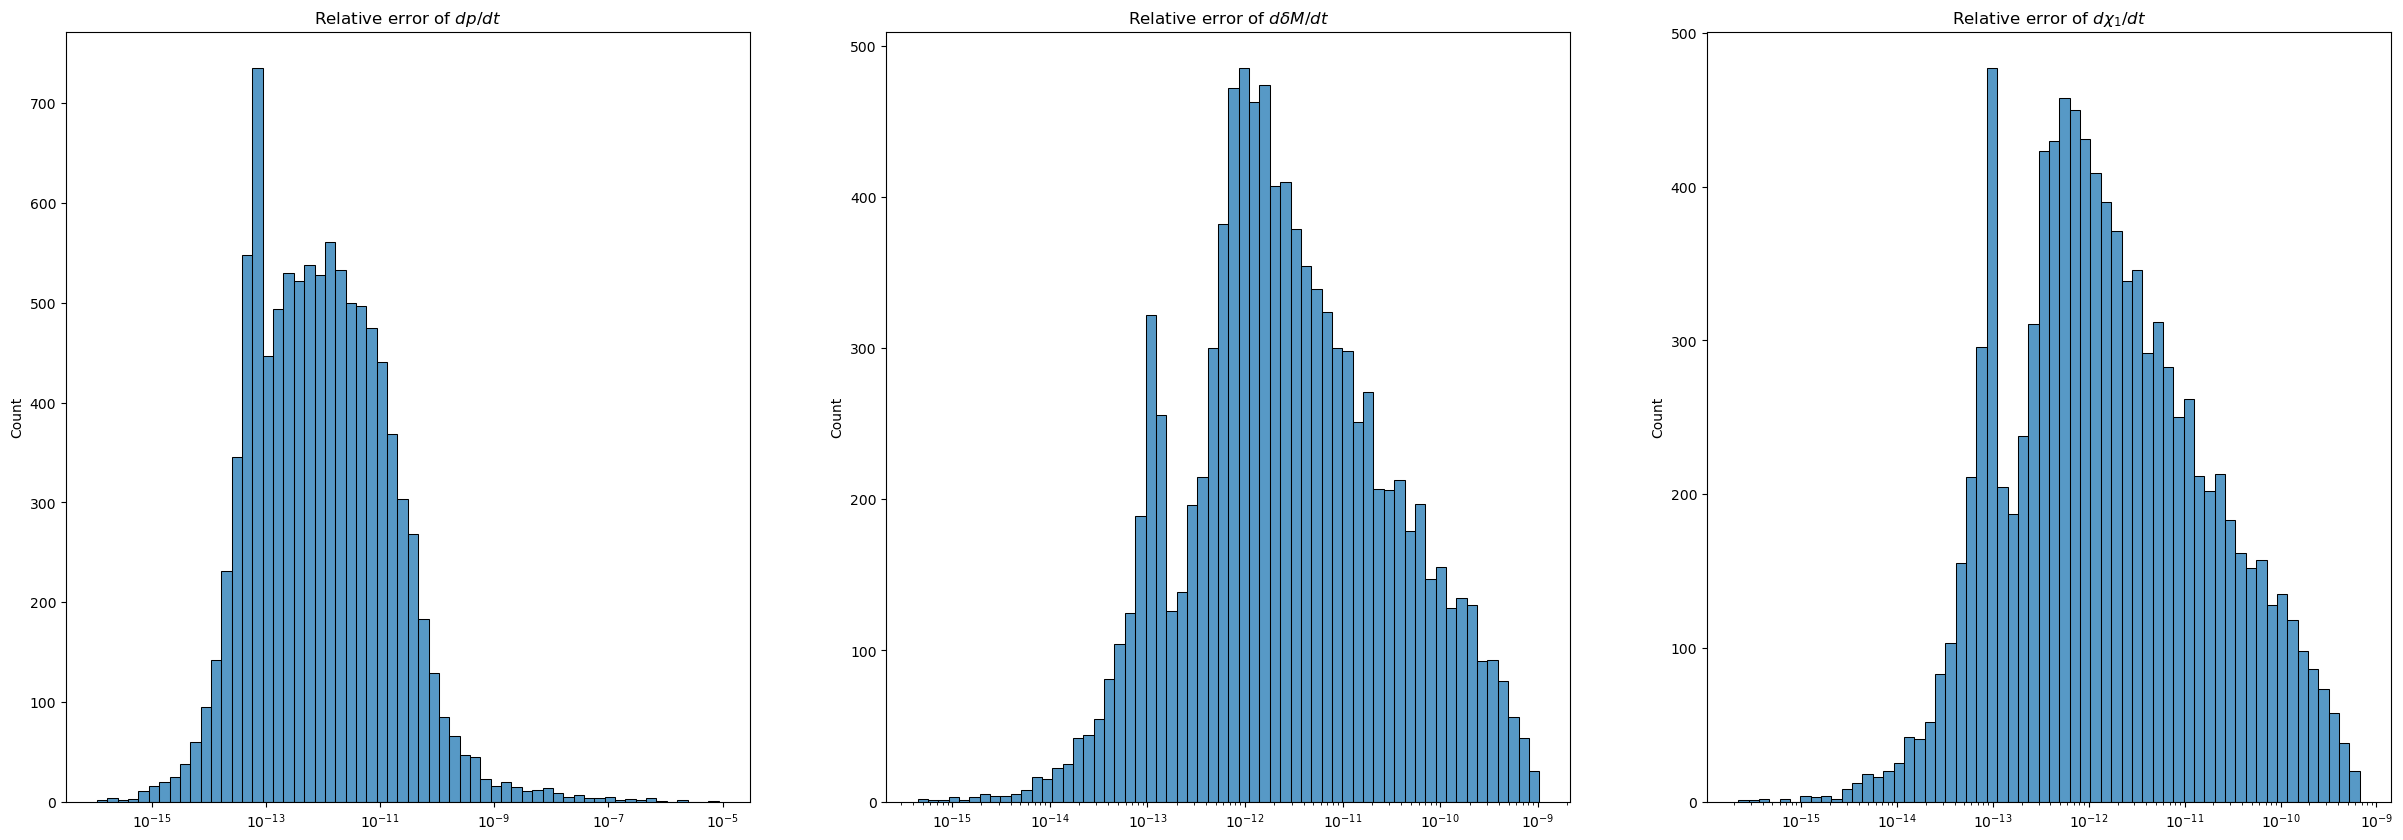

In [6]:
nbin=60
fig, axs = plt.subplots(1,3,figsize=(30,10))

sns.histplot(Fp_RelativeError, bins=nbin, log_scale=True, ax=axs[0])
axs[0].set(title=rf'Relative error of $dp/dt$')
sns.histplot(FdeltaM_RelativeError, bins=nbin, log_scale=True, ax=axs[1])
axs[1].set(title=rf'Relative error of $d\delta M/dt$')
sns.histplot(Fchit1_RelativeError, bins=nbin, log_scale=True, ax=axs[2])
axs[2].set(title=rf'Relative error of $d\chi_1/dt$')

plt.show()

# Trajectory Validation

In [7]:
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.IPAT1R import Trajectory1PAT1R
from few.summation.interpolatedmodesum import CubicSplineInterpolant
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import h5py

In [8]:
with h5py.File("TrajectoryWaSABI1PAT1R.h5", "r") as trajectoryData:
    timekeylist = [s for s in list(trajectoryData.keys()) if s.startswith("time")]
    p0, m10, m20, chi10, chi20, chit10 = np.array(trajectoryData["Grid"][:]).T
    nu = m10*m20/(m10+m20)**2.

    N_TESTS = len(p0)
    N_TIME = len(timekeylist)


    t_WaSABI = {}
    Omega_WaSABI = {}
    p_WaSABI = {}
    phi_WaSABI = {}
    nu_WaSABI = {}
    M_WaSABI = {}
    chit1_WaSABI = {}
    chit2_WaSABI = {}
    deltaM_WaSABI = {}
    deltachit1_WaSABI = {}
    for key in timekeylist:
        t_WaSABI[key] = np.array(trajectoryData[key + "/t"][:])
        Omega_WaSABI[key] = np.array(trajectoryData[key + "/Omega"][:])
        p_WaSABI[key] = Omega_WaSABI[key]**(-2./3.)
        phi_WaSABI[key] = np.array(trajectoryData[key + "/phi"][:])
        nu_WaSABI[key] = np.array(trajectoryData[key + "/nu"][:])
        M_WaSABI[key] = np.array(trajectoryData[key + "/M"][:])
        chit1_WaSABI[key] = np.array(trajectoryData[key + "/chit1"][:])
        chit2_WaSABI[key] = np.array(trajectoryData[key + "/chit2"][:])
        deltaM_WaSABI[key] = np.array(trajectoryData[key + "/deltam"][:])
        deltachit1_WaSABI[key] = chit1_WaSABI[key] - chit10

T=1e15
dt=1.0

In [9]:
p_FEW = {}
Omega_FEW = {}
deltaM_FEW = {}
deltachit1_FEW = {}
phi_FEW = {}

for key in timekeylist:
    p_FEW[key] = np.array([])
    Omega_FEW[key] = np.array([])
    deltaM_FEW[key] = np.array([])
    deltachit1_FEW[key] = np.array([])
    phi_FEW[key] = np.array([])

traj = EMRIInspiral(func=Trajectory1PAT1R)

for i in range(N_TESTS):
    t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
        m10[i], m20[i],
        chi10[i],        # chi1 (primary spin)
        p0[i],
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi20[i],
        T=T,
        dt=dt,
        in_coordinate_time=False,
    )

    # Example: Interpolate the semi-latus rectum (p)
    spline_p = CubicSplineInterpolant(t,p)
    spline_phi = CubicSplineInterpolant(t,Phi_phi)
    spline_deltaM = CubicSplineInterpolant(t,deltaM)
    spline_deltachit1 = CubicSplineInterpolant(t,deltachit1)

    for key in timekeylist:
        p_FEW[key] = np.append(p_FEW[key], spline_p(t_WaSABI[key][i]))
        deltaM_FEW[key] = np.append(deltaM_FEW[key], spline_deltaM(t_WaSABI[key][i]))
        deltachit1_FEW[key] = np.append(deltachit1_FEW[key], spline_deltachit1(t_WaSABI[key][i]))
        phi_FEW[key] = np.append(phi_FEW[key], spline_phi(t_WaSABI[key][i]))

In [10]:
p_RelativeError = {}
deltaM_RelativeError = {}
chit1_RelativeError = {}
phi_RelativeError = {}
phi_AbsoluteError = {}

for key in timekeylist:
    p_RelativeError[key] = np.abs((p_FEW[key] - p_WaSABI[key]) / p_WaSABI[key])
    deltaM_RelativeError[key] = np.abs((deltaM_FEW[key] - deltaM_WaSABI[key]) / deltaM_WaSABI[key])
    chit1_RelativeError[key] = np.abs((deltachit1_FEW[key] - deltachit1_WaSABI[key]) / deltachit1_WaSABI[key])
    phi_RelativeError[key] = np.abs((phi_FEW[key] - phi_WaSABI[key]) / phi_WaSABI[key])
    phi_AbsoluteError[key] = np.abs(phi_FEW[key] - phi_WaSABI[key])

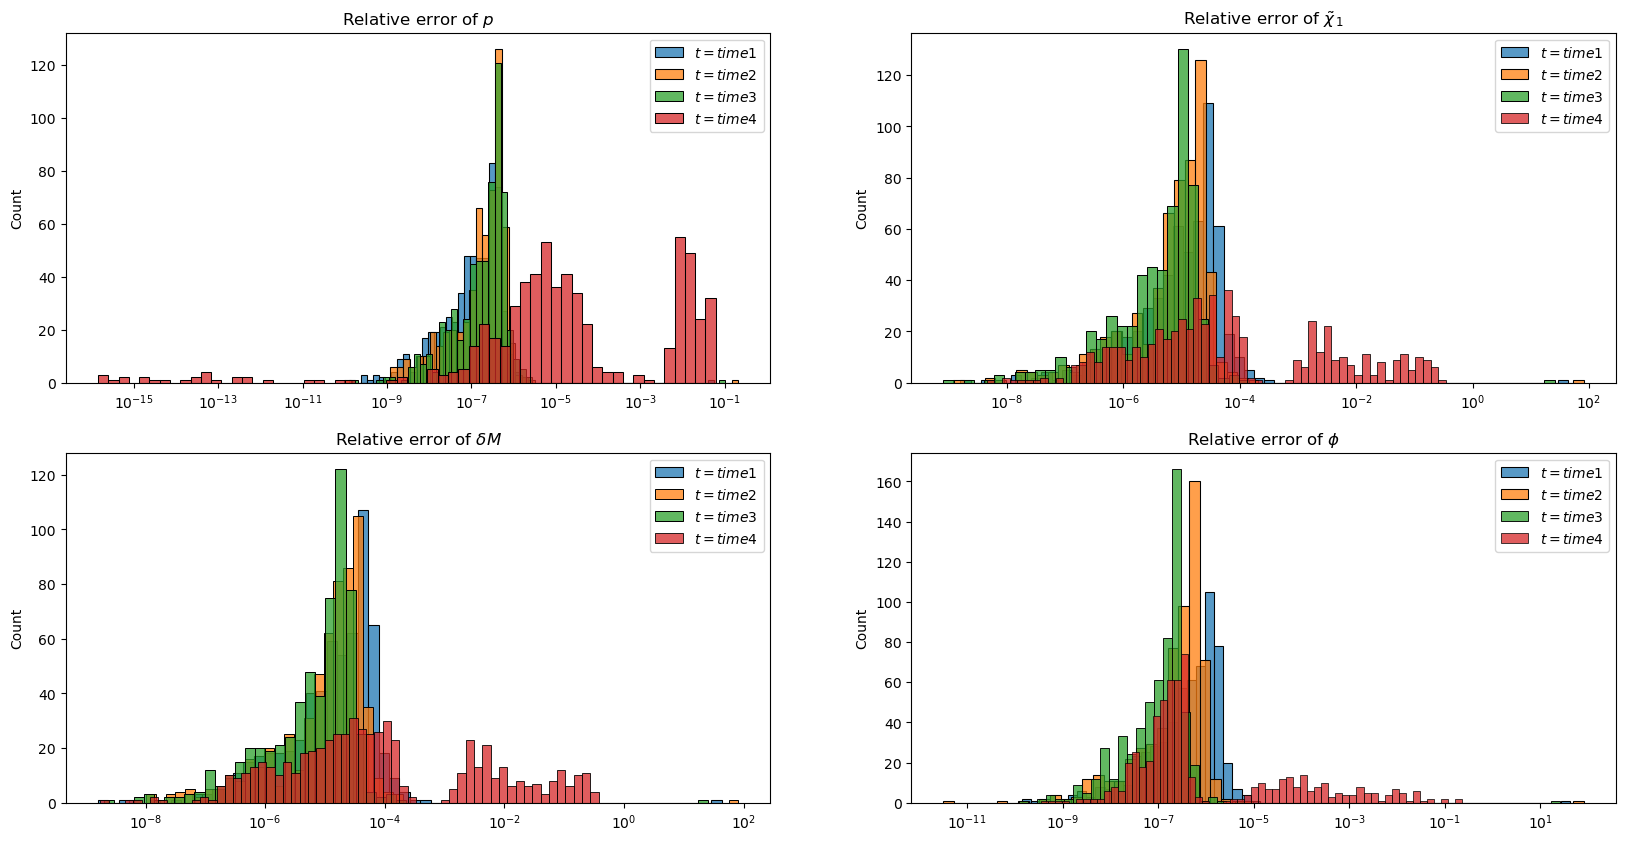

In [11]:
nbin=60
fig, axs = plt.subplots(2,2,figsize=(20,10))

axs[0, 0].set(title=rf'Relative error of $p$')
for key in timekeylist:
    sns.histplot(p_RelativeError[key], bins=nbin, log_scale=True, ax=axs[0, 0], label=rf'$t={key}$')
axs[0, 0].legend()

axs[1, 0].set(title=rf'Relative error of $\delta M$')
for key in timekeylist:
    sns.histplot(deltaM_RelativeError[key], bins=nbin, log_scale=True, ax=axs[1, 0], label=rf'$t={key}$')
axs[1, 0].legend()

axs[0, 1].set(title=rf'Relative error of $\tilde\chi_1$')
for key in timekeylist:
    sns.histplot(chit1_RelativeError[key], bins=nbin, log_scale=True, ax=axs[0, 1], label=rf'$t={key}$')
axs[0, 1].legend()

axs[1, 1].set(title=rf'Relative error of $\phi$')
for key in timekeylist:
    sns.histplot(phi_RelativeError[key], bins=nbin, log_scale=True, ax=axs[1, 1], label=rf'$t={key}$')
axs[1, 1].legend()

plt.show()

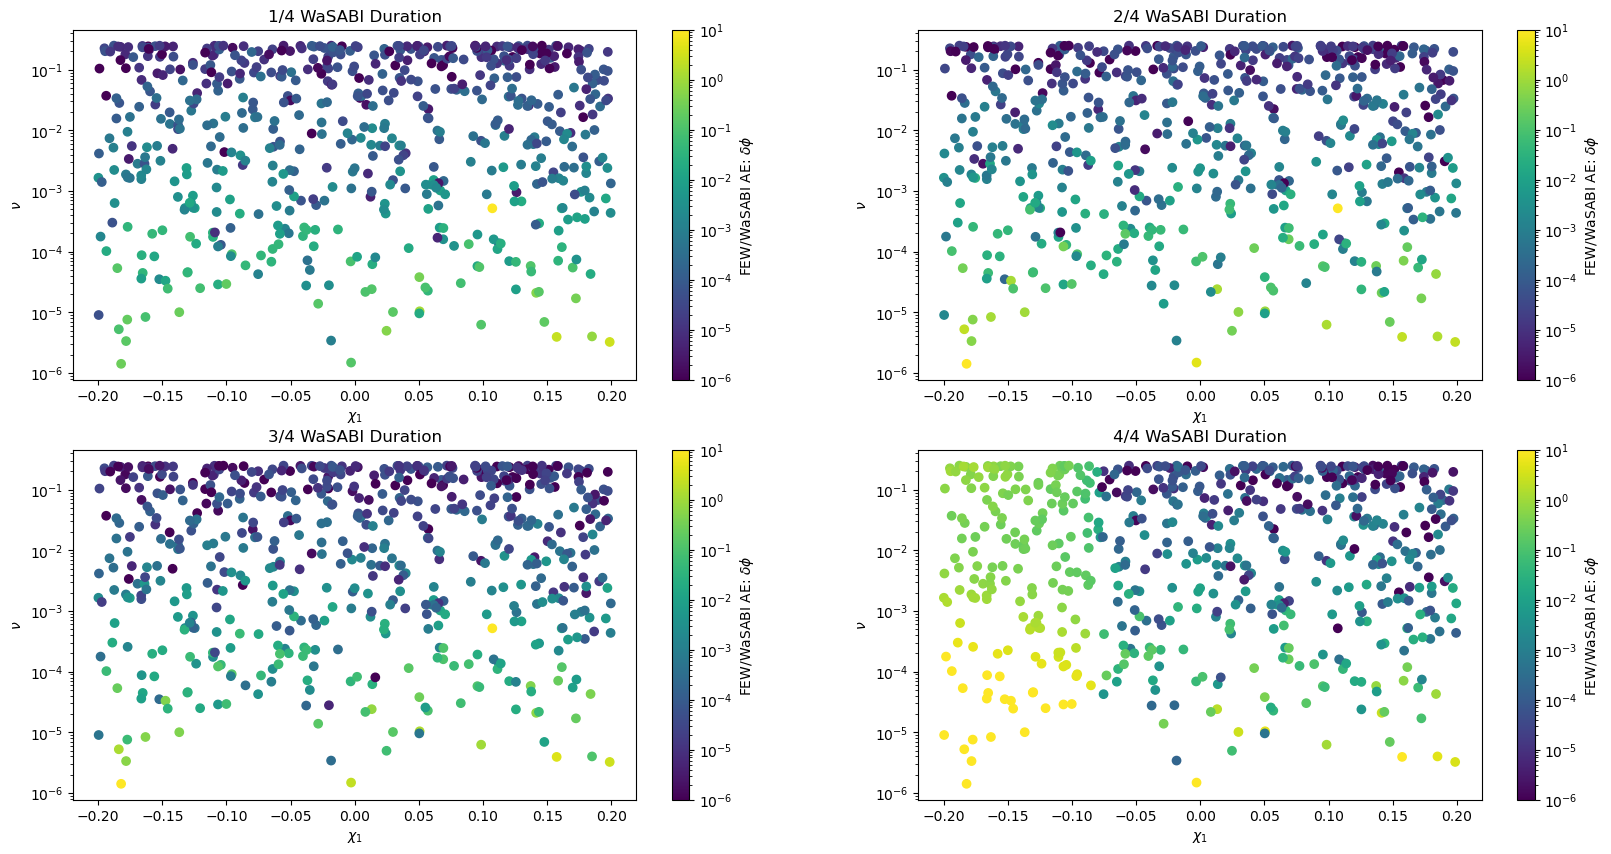

In [12]:
fig, axs = plt.subplots(2,2,figsize=(20,10))
axs = axs.flatten()

for i,key in enumerate(timekeylist):
    ax=axs[i]
    sc = ax.scatter(chi10, nu, c=phi_AbsoluteError[key], cmap='viridis', norm='log', vmin=1e-6, vmax=1e1)
    cbar = ax.figure.colorbar(sc, ax=ax, label=rf'FEW/WaSABI AE: $\delta\phi$')
    ax.set_yscale("log")
    ax.set_xlabel(r'$\chi_{1}$')
    ax.set_ylabel(r'$\nu$')
    ax.set_title(f"{str(i+1)+'/'+str(len(timekeylist))+' WaSABI Duration'}")


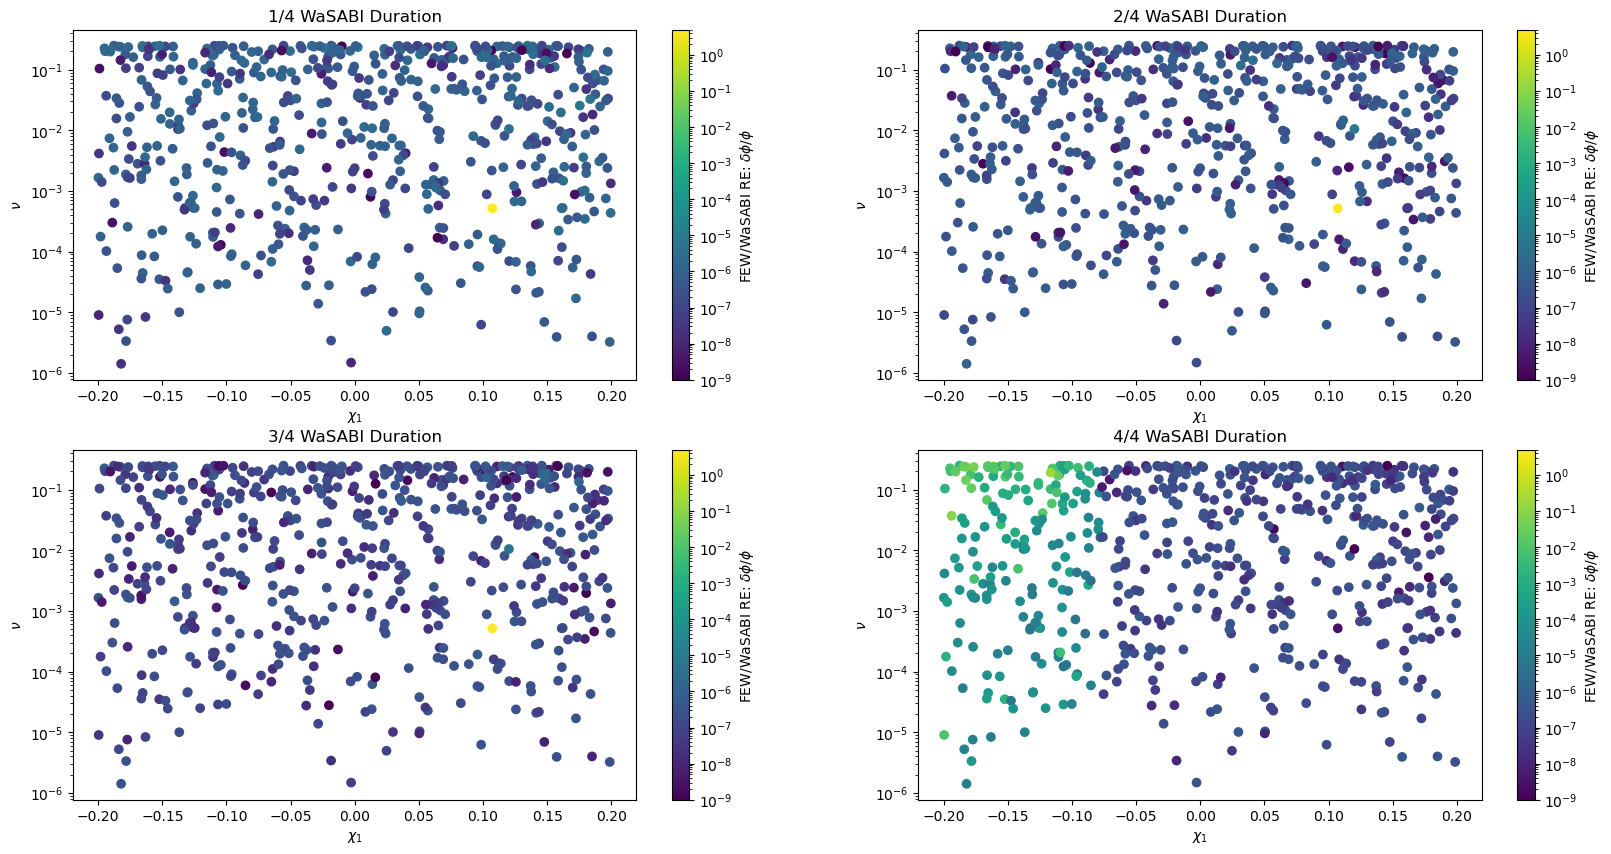

In [13]:
fig, axs = plt.subplots(2,2,figsize=(20,10))
axs = axs.flatten()

for i,key in enumerate(timekeylist):
    ax=axs[i]
    sc = ax.scatter(chi10, nu, c=phi_RelativeError[key], cmap='viridis', norm='log', vmin=1e-9, vmax=1e1-5)
    cbar = ax.figure.colorbar(sc, ax=ax, label=rf'FEW/WaSABI RE: $\delta\phi/\phi$')
    ax.set_yscale("log")
    ax.set_xlabel(r'$\chi_{1}$')
    ax.set_ylabel(r'$\nu$')
    ax.set_title(f"{str(i+1)+'/'+str(len(timekeylist))+' WaSABI Duration'}")


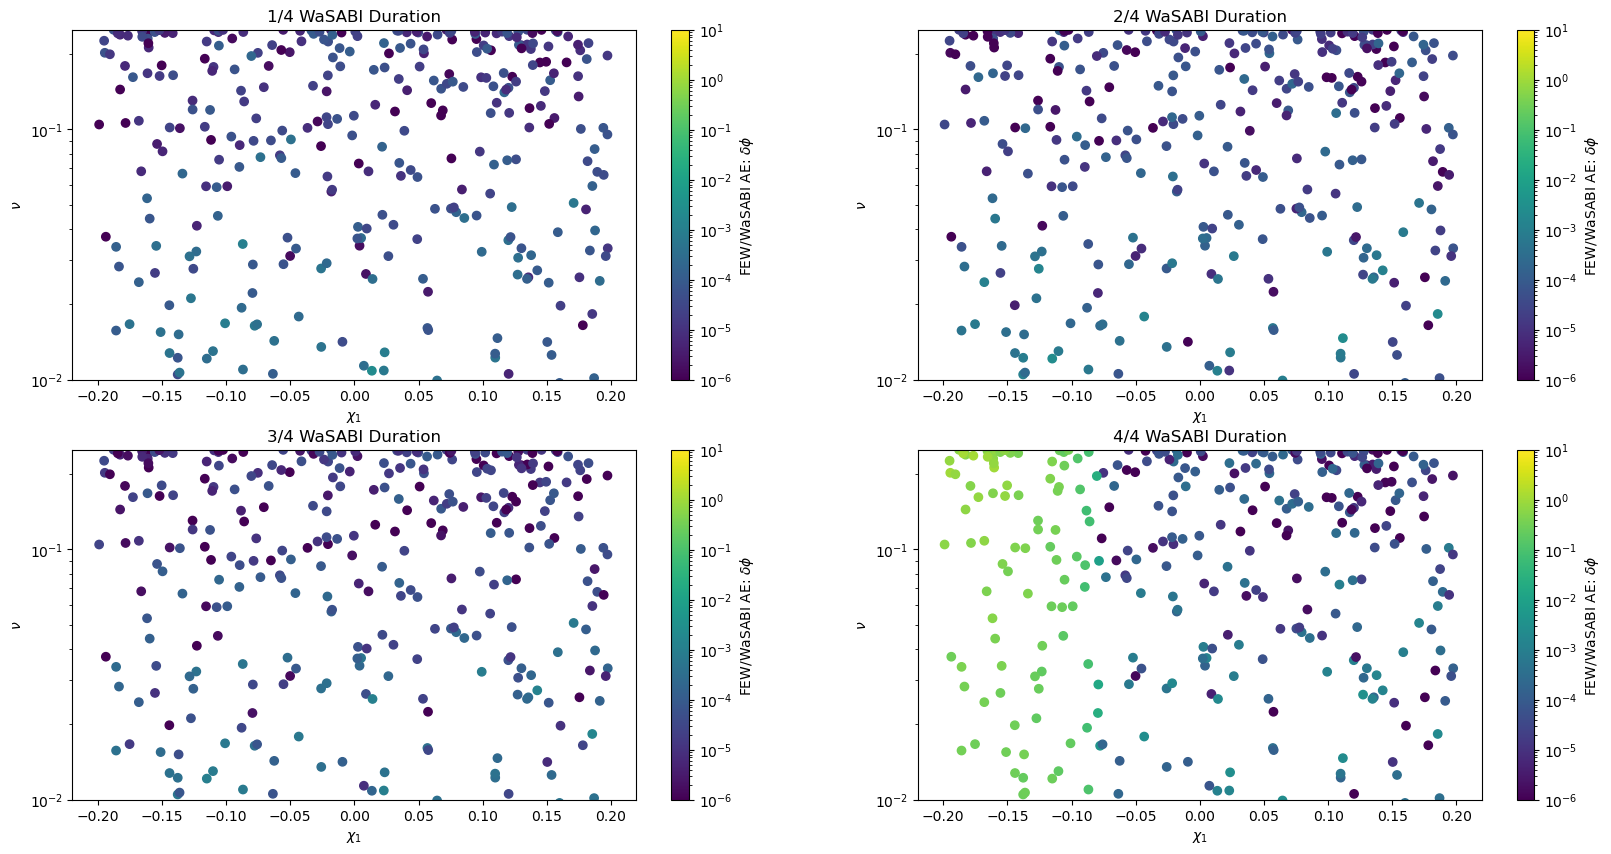

In [14]:
fig, axs = plt.subplots(2,2,figsize=(20,10))
axs = axs.flatten()

for i,key in enumerate(timekeylist):
    ax=axs[i]
    sc = ax.scatter(chi10, nu, c=phi_AbsoluteError[key], cmap='viridis', norm='log', vmin=1e-6, vmax=1e1)
    cbar = ax.figure.colorbar(sc, ax=ax, label=rf'FEW/WaSABI AE: $\delta\phi$')
    ax.set_yscale("log")
    ax.set_xlabel(r'$\chi_{1}$')
    ax.set_ylabel(r'$\nu$')
    ax.set_title(f"{str(i+1)+'/'+str(len(timekeylist))+' WaSABI Duration'}")
    ax.set_ylim(1e-2,.25)


# Dephasing

In [15]:
t_WaSABI = []
p_WaSABI = []
phi_WaSABI = []

with h5py.File("PhaseWaSABI1PAT1R.h5", "r") as trajectoryData:
    p0, m10, m20, chi10, chi20, chit10 = np.array(trajectoryData["Grid"][:]).T
    N_TESTS = len(p0)

    nu = m10*m20/(m10+m20)**2.

    for i in range(N_TESTS):
        t_WaSABI.append(np.array(trajectoryData[str(i+1)][0, :]))
        p_WaSABI.append(np.array(trajectoryData[str(i+1)][1, :]))
        phi_WaSABI.append(np.array(trajectoryData[str(i+1)][2, :]))

T=1e25
dt=1.0

In [16]:
phi_FEW = []
p_FEW = []

traj = EMRIInspiral(func=Trajectory1PAT1R)

for i in range(N_TESTS):
    t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
        m10[i], m20[i],
        chi10[i],        # chi1 (primary spin)
        p0[i],
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        chi20[i],
        T=T,
        dt=dt,
        in_coordinate_time=False,
    )

    # Example: Interpolate the semi-latus rectum (p)
    spline_phi = CubicSplineInterpolant(t,Phi_phi)
    spline_p = CubicSplineInterpolant(t,p)
    phi_FEW.append(spline_phi(t_WaSABI[i]))
    p_FEW.append(spline_p(t_WaSABI[i]))

In [17]:
deltaphi = []

for i in range(N_TESTS):
    deltaphi.append(np.abs(phi_FEW[i] - phi_WaSABI[i]))

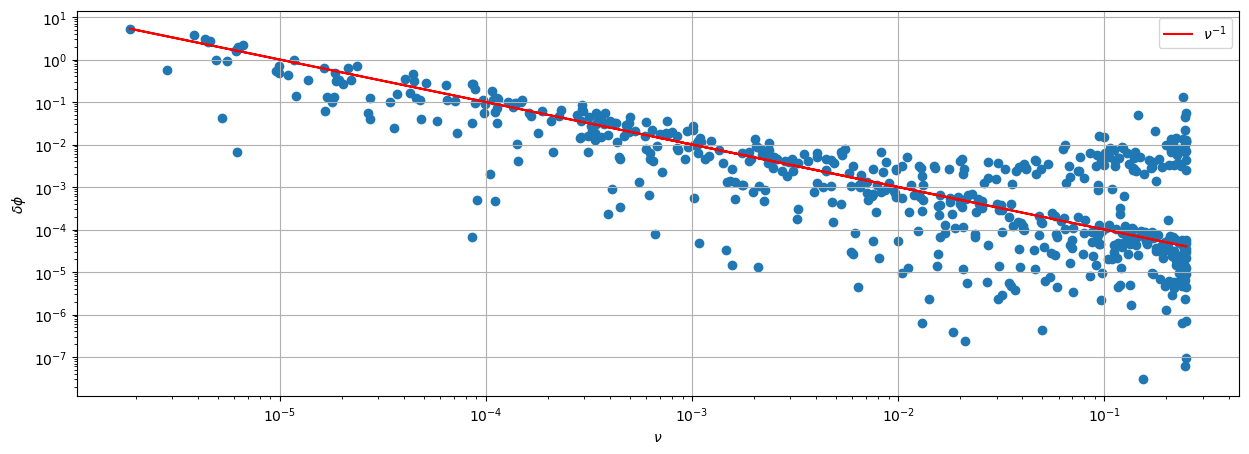

In [18]:
plt.figure(figsize=(15,5))
plt.scatter(nu, [np.mean(deltaphi[i]) for i in range(N_TESTS)])
plt.plot(nu, 1e-5 * nu**(-1),c='r',label=r'$\nu^{-1}$')
plt.yscale("log")
plt.xscale("log")
plt.xlabel(r'$\nu$')
plt.ylabel(r'$\delta \phi$')
plt.legend()
plt.grid()
plt.show()

/var/folders/61/zcyl6fqn2sd49qxb8hd1hl740000gn/T/ipykernel_20664/4280391976.py:20: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim([.0, 50])


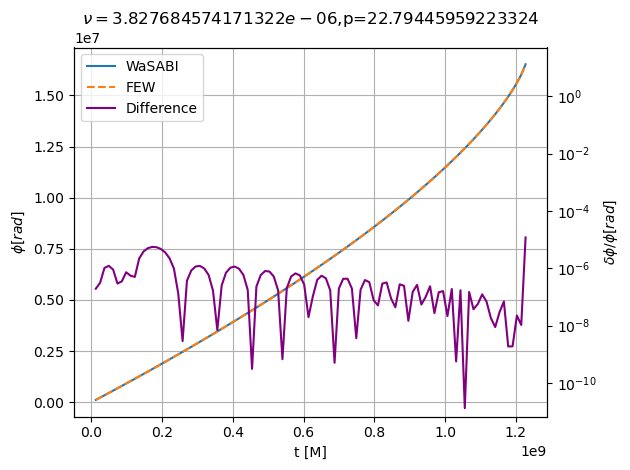

In [19]:
i=100

fig, ax1 = plt.subplots()

ax1.set_xlabel(r't [M]')
ax1.set_ylabel(r'$\phi [rad]$')
ax1.plot(t_WaSABI[i], phi_WaSABI[i],label='WaSABI')
ax1.plot(t_WaSABI[i], phi_FEW[i], linestyle='dashed',label='FEW')
ax1.plot([],label='Difference',c='purple')
plt.grid()
plt.legend()
ax1.tick_params(axis='y')

ax2 = ax1.twinx()

ax2.set_ylabel(r'$\delta \phi/\phi [rad]$')
ax2.plot(t_WaSABI[i], deltaphi[i]/phi_FEW[i],label='relative difference',c='purple')
ax2.tick_params(axis='y')
plt.yscale("log")
plt.ylim([.0, 50])

plt.title(fr'$\nu={nu[i]}$,p={p0[i]}')
fig.tight_layout()
plt.show()

In [20]:
nu_WaSABI = {}
t_WaSABI = {}
p_WaSABI = {}
phi_WaSABI = {}
m10 = {}
m20 = {}

with h5py.File("FixedParameterDephasing.h5", "r") as trajectoryData:
    
    N_TESTS = len(trajectoryData.keys())

    for key in trajectoryData.keys():
        nu_WaSABI[key] = 10**trajectoryData[key][0]
        t_WaSABI[key] = trajectoryData[key][1]
        p_WaSABI[key] = trajectoryData[key][2]
        phi_WaSABI[key] = trajectoryData[key][3]
        m10[key] = (1+np.sqrt(1-4*nu_WaSABI[key]))/2
        m20[key] = (1-np.sqrt(1-4*nu_WaSABI[key]))/2

T=1e25
dt=1.0

In [21]:
phi_FEW = {}
p_FEW = {}

traj = EMRIInspiral(func=Trajectory1PAT1R)

for key in nu_WaSABI.keys():
    t, p, e, x, Phi_phi, Phi_theta, Phi_r, deltaM, deltachit1 = traj(
        m10[key], m20[key],
        0.0,        # chi1 (primary spin)
        12.0,
        0.0,      # e0: circular
        1.0,      # xI: equatorial prograde
        0.0,
        T=T,
        dt=dt,
        in_coordinate_time=False,
    )

    # Example: Interpolate the semi-latus rectum (p)
    spline_phi = CubicSplineInterpolant(t,Phi_phi)
    spline_p = CubicSplineInterpolant(t,p)
    phi_FEW[key] = spline_phi(t_WaSABI[key])
    p_FEW[key] = spline_p(t_WaSABI[key])

In [22]:
deltaphi = {}

for key in nu_WaSABI.keys():
    deltaphi[key] = np.abs(phi_FEW[key] - phi_WaSABI[key])

Text(0, 0.5, '$\\delta \\phi$')

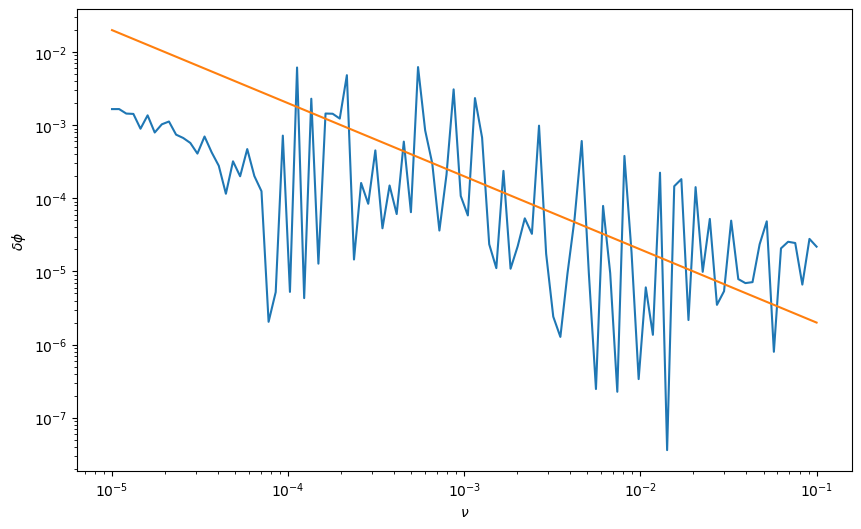

In [23]:
plt.figure(figsize=(10, 6))
plt.plot([nu_WaSABI[key] for key in nu_WaSABI.keys()], [deltaphi[key] for key in deltaphi.keys()])
plt.plot([nu_WaSABI[key] for key in nu_WaSABI.keys()], [2e-7*nu_WaSABI[key]**(-1) for key in deltaphi.keys()])
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$\nu$')
plt.ylabel(r'$\delta \phi$')